<a href="https://colab.research.google.com/github/fellAR-hub/Probabilidad/blob/main/unidad5/proyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Probabilidad y estadisticas
#unidad 5
##Practica final
###Facilitador:Jose Gabriel Rodriguez rivas
###Alumno:Abrego Reyes Angel Felipe

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

grupo1 = pd.read_csv("grupo1.csv")
grupo2 = pd.read_csv("grupo2.csv")
grupo3 = pd.read_csv("grupo3.csv")

print("Grupo 1:", grupo1.head())
print("Grupo 2:",grupo2.head())
print("Grupo 3:",grupo3.head())

Grupo 1:    HorasEstudio  Calificacion
0         20.00         75.94
1         15.60         87.48
2         17.91         79.40
3         20.00         73.37
4         20.00         83.75
Grupo 2:    HorasEstudio  Calificacion
0          3.79          40.0
1          6.08          26.1
2          7.17          29.0
3          7.54          31.9
4          8.18          34.8
Grupo 3:    HorasEstudio  Calificacion
0          3.79          15.0
1          6.08          26.1
2          7.17          29.0
3          7.54          31.9
4          8.18          34.8


In [9]:
for i, grupo in enumerate([grupo1, grupo2, grupo3], 1):
    print(f"\n========== GRUPO {i} ==========")
    print(grupo.describe())


========== GRUPO 1 ==========
       HorasEstudio  Calificacion
count     50.000000      50.00000
mean      14.352000      83.78820
std        4.219174       7.83389
min        3.790000      68.46000
25%       12.032500      78.03500
50%       14.600000      84.49000
75%       17.715000      88.09000
max       20.000000     100.00000

========== GRUPO 2 ==========
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.912000
std        4.219174     20.668922
min        3.790000     26.100000
25%       12.032500     63.500000
50%       14.600000     78.550000
75%       17.715000     93.300000
max       20.000000     99.000000

========== GRUPO 3 ==========
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.968000
std        4.219174     23.668867
min        3.790000     15.000000
25%       12.032500     61.000000
50%       14.600000     84.950000
75%       17.715000     94.375000
max       20.000000    

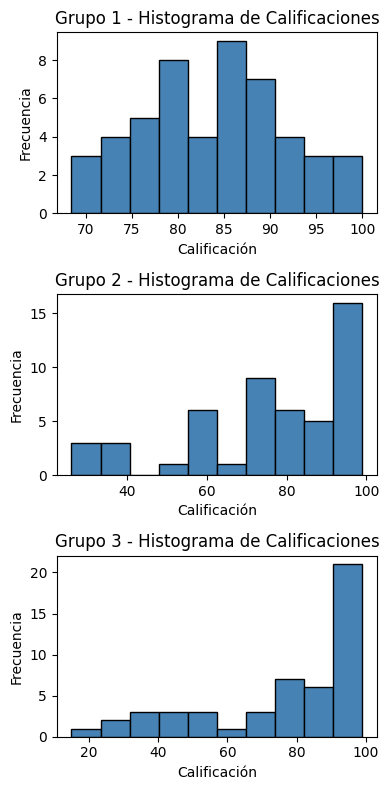

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(4, 8))

ax1.hist(grupo1["Calificacion"], bins=10, color="steelblue", edgecolor="black")
ax1.set_title("Grupo 1 - Histograma de Calificaciones")
ax1.set_xlabel("Calificación")
ax1.set_ylabel("Frecuencia")

ax2.hist(grupo2["Calificacion"], bins=10, color="steelblue", edgecolor="black")
ax2.set_title("Grupo 2 - Histograma de Calificaciones")
ax2.set_xlabel("Calificación")
ax2.set_ylabel("Frecuencia")

ax3.hist(grupo3["Calificacion"], bins=10, color="steelblue", edgecolor="black")
ax3.set_title("Grupo 3 - Histograma de Calificaciones")
ax3.set_xlabel("Calificación")
ax3.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [34]:
for i, grupo in enumerate([grupo1, grupo2, grupo3], 1):
    x = grupo["HorasEstudio"].values.reshape(-1, 1)
    y = grupo["Calificacion"].values

    modelo = LinearRegression()
    modelo.fit(x, y)

    pendiente   = modelo.coef_[0]
    intercepto  = modelo.intercept_
    r, p_valor  = stats.pearsonr(grupo["HorasEstudio"], grupo["Calificacion"])

    print(f"\n========== GRUPO {i} ==========")
    print(f"Ecuación: Calificación = {pendiente:.2f} * HorasEstudio + {intercepto:.2f}")
    print(f"Correlación de Pearson (r): {r:.2f}")
    print(f"P-valor: {p_valor:.4f}")
    print(f"R² (coef. determinación): {r**2:.2f}")


========== GRUPO 1 ==========
Ecuación: Calificación = -0.11 * HorasEstudio + 85.31
Correlación de Pearson (r): -0.06
P-valor: 0.6935
R² (coef. determinación): 0.00

========== GRUPO 2 ==========
Ecuación: Calificación = 4.22 * HorasEstudio + 15.31
Correlación de Pearson (r): 0.86
P-valor: 0.0000
R² (coef. determinación): 0.74

========== GRUPO 3 ==========
Ecuación: Calificación = 5.29 * HorasEstudio + 0.11
Correlación de Pearson (r): 0.94
P-valor: 0.0000
R² (coef. determinación): 0.89


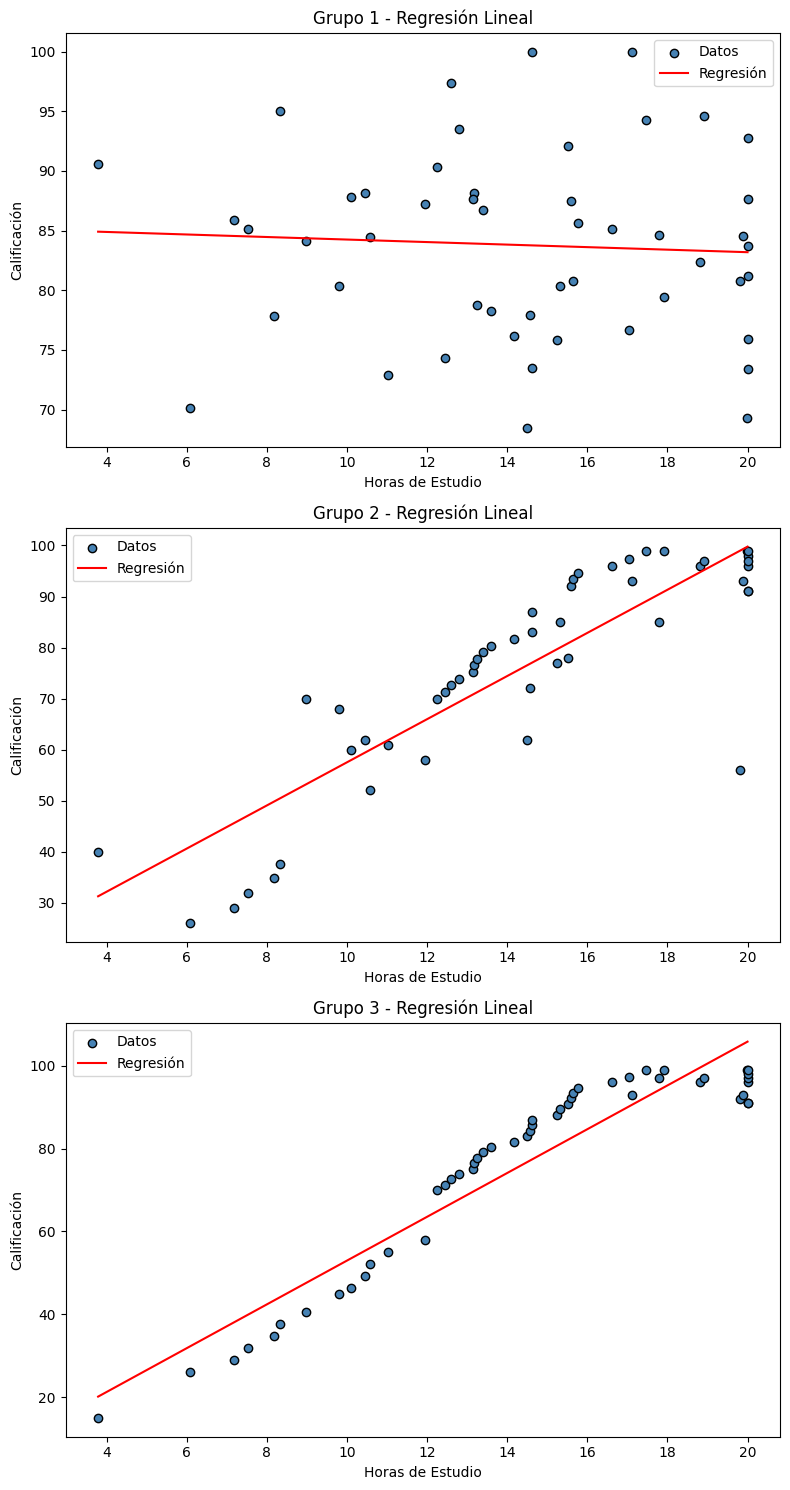

In [38]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8, 15))

# ===== GRUPO 1 =====
x1 = grupo1["HorasEstudio"].values.reshape(-1, 1)
y1 = grupo1["Calificacion"].values

modelo1 = LinearRegression()
modelo1.fit(x1, y1)

x_linea1 = np.linspace(x1.min(), x1.max(), 100).reshape(-1, 1)
y_linea1 = modelo1.predict(x_linea1)

ax1.scatter(grupo1["HorasEstudio"], grupo1["Calificacion"],
            color="steelblue", edgecolor="black", label="Datos")
ax1.plot(x_linea1, y_linea1, color="red", label="Regresión")
ax1.set_title("Grupo 1 - Regresión Lineal")
ax1.set_xlabel("Horas de Estudio")
ax1.set_ylabel("Calificación")
ax1.legend()

# ===== GRUPO 2 =====
x2 = grupo2["HorasEstudio"].values.reshape(-1, 1)
y2 = grupo2["Calificacion"].values

modelo2 = LinearRegression()
modelo2.fit(x2, y2)

x_linea2 = np.linspace(x2.min(), x2.max(), 100).reshape(-1, 1)
y_linea2 = modelo2.predict(x_linea2)

ax2.scatter(grupo2["HorasEstudio"], grupo2["Calificacion"],
            color="steelblue", edgecolor="black", label="Datos")
ax2.plot(x_linea2, y_linea2, color="red", label="Regresión")
ax2.set_title("Grupo 2 - Regresión Lineal")
ax2.set_xlabel("Horas de Estudio")
ax2.set_ylabel("Calificación")
ax2.legend()

# ===== GRUPO 3 =====
x3 = grupo3["HorasEstudio"].values.reshape(-1, 1)
y3 = grupo3["Calificacion"].values

modelo3 = LinearRegression()
modelo3.fit(x3, y3)

x_linea3 = np.linspace(x3.min(), x3.max(), 100).reshape(-1, 1)
y_linea3 = modelo3.predict(x_linea3)

ax3.scatter(grupo3["HorasEstudio"], grupo3["Calificacion"],
            color="steelblue", edgecolor="black", label="Datos")
ax3.plot(x_linea3, y_linea3, color="red", label="Regresión")
ax3.set_title("Grupo 3 - Regresión Lineal")
ax3.set_xlabel("Horas de Estudio")
ax3.set_ylabel("Calificación")
ax3.legend()

plt.tight_layout()
plt.show()